# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse (SARIMA)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [17]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData1.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=['sheet1', 'sheet2', 'sheet3']) # Load all the desired sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [18]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:04:46,2,02/27/2025 10:04:46 AM,80.19,78.64,76.12,77.16,78.88,78.26,sheet1
2025-02-27 10:04:48,3,02/27/2025 10:04:48 AM,80.21,78.65,76.10,77.14,78.87,78.24,sheet1
2025-02-27 10:04:50,4,02/27/2025 10:04:50 AM,80.06,78.64,76.12,77.17,78.87,78.12,sheet1
2025-02-27 10:04:52,5,02/27/2025 10:04:52 AM,80.06,78.64,76.12,77.18,78.88,78.12,sheet1


In [19]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 196602 entries, 2025-02-27 10:04:44 to 2025-03-03 23:18:06
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        196602 non-null  int64  
 1   Time         196602 non-null  str    
 2   CH01(%)      196602 non-null  float64
 3   CH02(%)      196602 non-null  float64
 4   CH03(%)      196602 non-null  float64
 5   CH04(%)      196602 non-null  float64
 6   CH05(%)      196602 non-null  float64
 7   CH06(%)      196602 non-null  float64
 8   SourceSheet  196602 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 15.0 MB


In [20]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [21]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 196602 entries, 2025-02-27 10:04:44 to 2025-03-03 23:18:06
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        196602 non-null  int64  
 1   CH01(%)      196602 non-null  float64
 2   CH02(%)      196602 non-null  float64
 3   CH03(%)      196602 non-null  float64
 4   CH04(%)      196602 non-null  float64
 5   CH05(%)      196602 non-null  float64
 6   CH06(%)      196602 non-null  float64
 7   SourceSheet  196602 non-null  str    
dtypes: float64(6), int64(1), str(1)
memory usage: 13.5 MB


In [22]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [23]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [24]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 196602 entries, 2025-02-27 10:04:44 to 2025-03-03 23:18:06
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Index    196602 non-null  int64  
 1   CH01(%)  196602 non-null  float64
 2   CH02(%)  196602 non-null  float64
 3   CH03(%)  196602 non-null  float64
 4   CH04(%)  196602 non-null  float64
 5   CH05(%)  196602 non-null  float64
 6   CH06(%)  196602 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 12.0 MB


In [25]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:04:46,2,80.19,78.64,76.12,77.16,78.88,78.26
2025-02-27 10:04:48,3,80.21,78.65,76.10,77.14,78.87,78.24
2025-02-27 10:04:50,4,80.06,78.64,76.12,77.17,78.87,78.12
2025-02-27 10:04:52,5,80.06,78.64,76.12,77.18,78.88,78.12


C:\Users\sulaiman.at\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


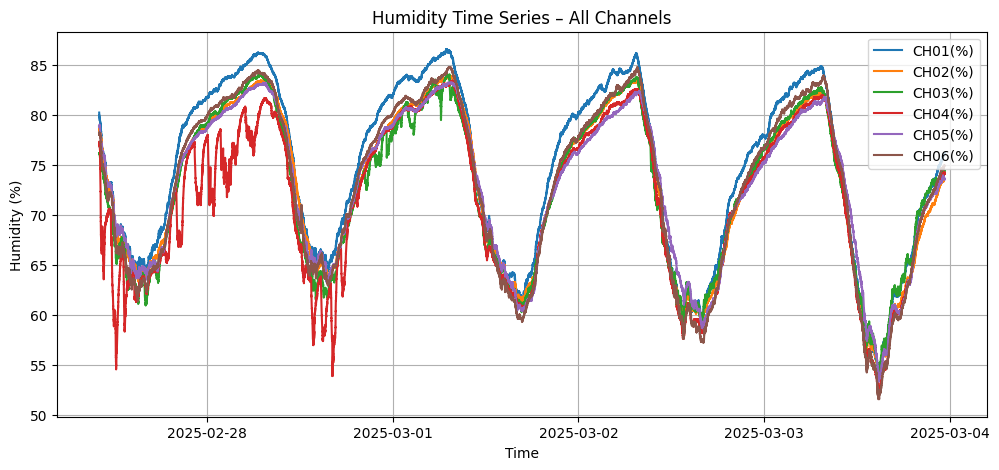

In [26]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
# Perform ADF test for each channel
for column in combined_df.columns:
    print(f"ADF Test for {column}:")
    result = adfuller(combined_df[column].dropna()) # dropna() to handle potential missing values
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    print(f"Is Stationary: {result[1] < 0.05}\n")

ADF Test for CH01(%):
ADF Statistic: -0.9126821645782563
p-value: 0.7837673138258766
Critical Values: {'1%': np.float64(-3.4303832757589157), '5%': np.float64(-2.8615547074437124), '10%': np.float64(-2.5667778282437683)}
Is Stationary: False

ADF Test for CH02(%):
ADF Statistic: -0.8823652829882143
p-value: 0.7937242994867446
Critical Values: {'1%': np.float64(-3.4303832757589157), '5%': np.float64(-2.8615547074437124), '10%': np.float64(-2.5667778282437683)}
Is Stationary: False

ADF Test for CH03(%):
ADF Statistic: -1.0142440104383237
p-value: 0.7480337384114604
Critical Values: {'1%': np.float64(-3.430383270341353), '5%': np.float64(-2.8615547050492354), '10%': np.float64(-2.566777826969272)}
Is Stationary: False

ADF Test for CH04(%):
ADF Statistic: -1.8477912168851116
p-value: 0.3570058483892099
Critical Values: {'1%': np.float64(-3.4303832757589157), '5%': np.float64(-2.8615547074437124), '10%': np.float64(-2.5667778282437683)}
Is Stationary: False

ADF Test for CH05(%):
ADF Stat

**Remove the trend**

In [28]:
first_diff = combined_df.diff()
first_diff.dropna(inplace=True)

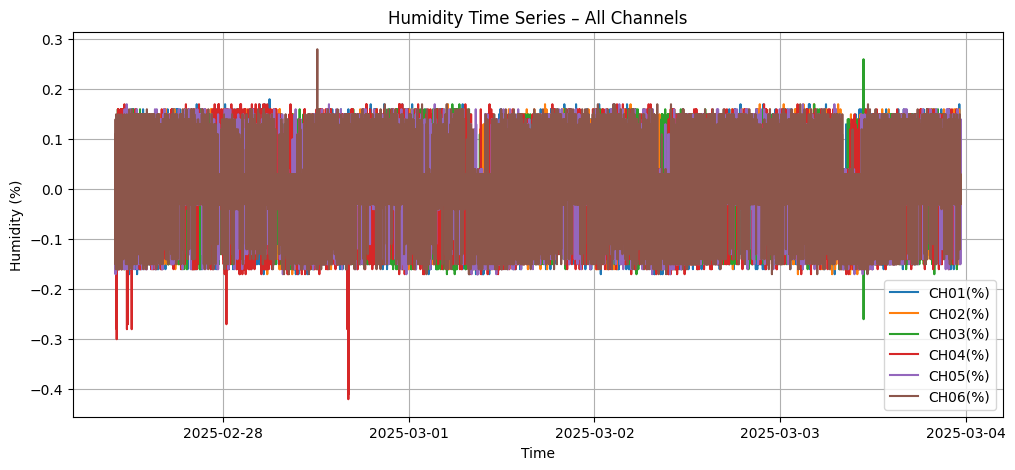

In [29]:
plt.figure(figsize=(12,5))
for col in first_diff.columns:
    plt.plot(first_diff.index, first_diff[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
# Perform ADF test for each channel on first difference
for column in first_diff.columns:
    print(f"ADF Test for {column}:")
    result = adfuller(first_diff[column].dropna()) # dropna() to handle potential missing values
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    print(f"Is Stationary: {result[1] < 0.05}\n")

ADF Test for CH01(%):
ADF Statistic: -36.168447007342266
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430383275928243), '5%': np.float64(-2.8615547075185526), '10%': np.float64(-2.566777828283603)}
Is Stationary: True

ADF Test for CH02(%):
ADF Statistic: -36.31844803637625
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430383275928243), '5%': np.float64(-2.8615547075185526), '10%': np.float64(-2.566777828283603)}
Is Stationary: True

ADF Test for CH03(%):
ADF Statistic: -53.6122035206921
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430383270341353), '5%': np.float64(-2.8615547050492354), '10%': np.float64(-2.566777826969272)}
Is Stationary: True

ADF Test for CH04(%):
ADF Statistic: -33.318007423110565
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4303832757589157), '5%': np.float64(-2.8615547074437124), '10%': np.float64(-2.5667778282437683)}
Is Stationary: True

ADF Test for CH05(%):
ADF Statistic: -35.22055636937994
p-value: 0.0
Critical Values: {'1%': np.float

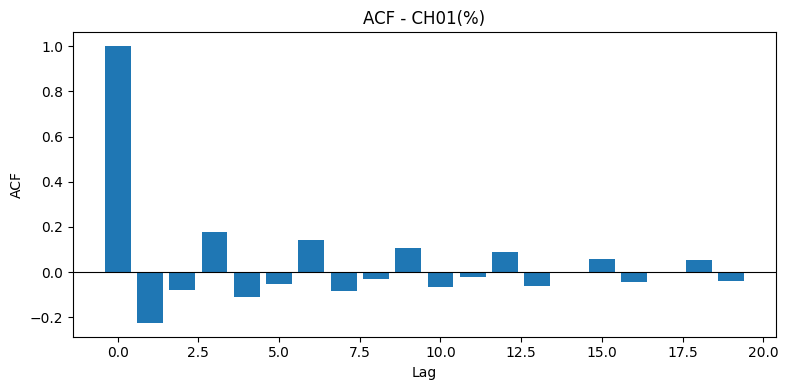

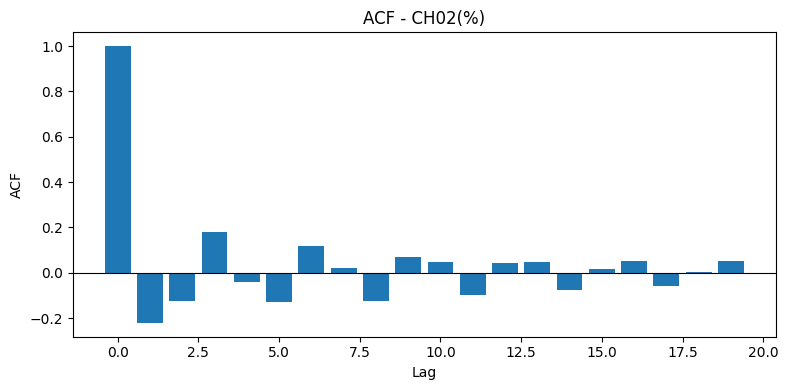

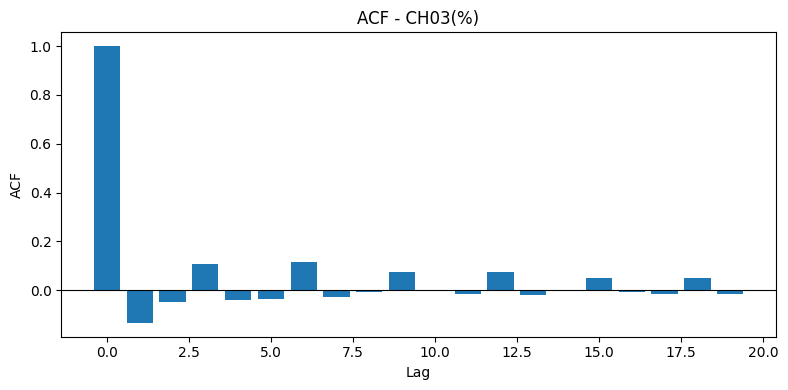

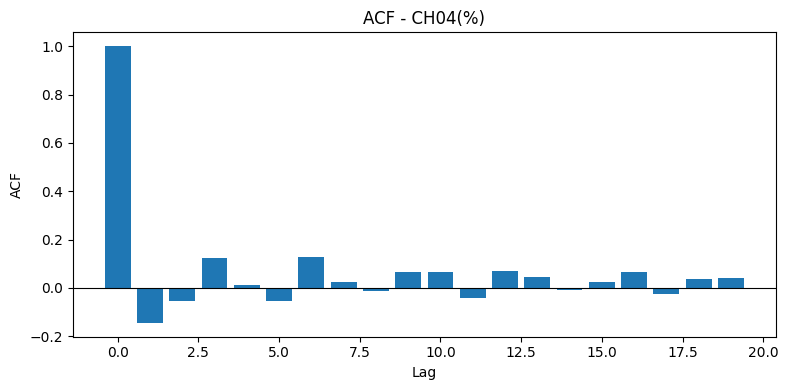

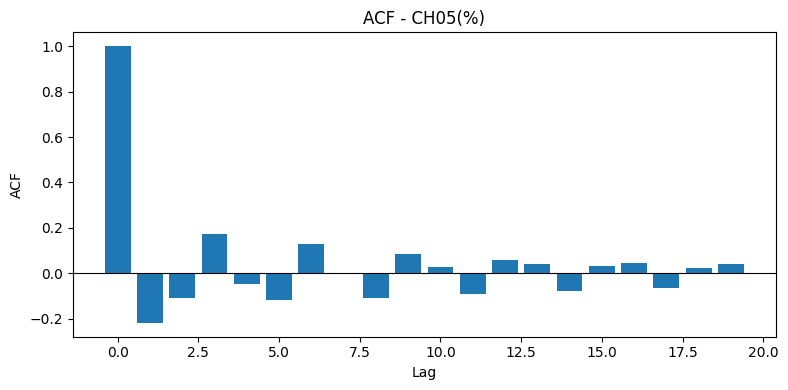

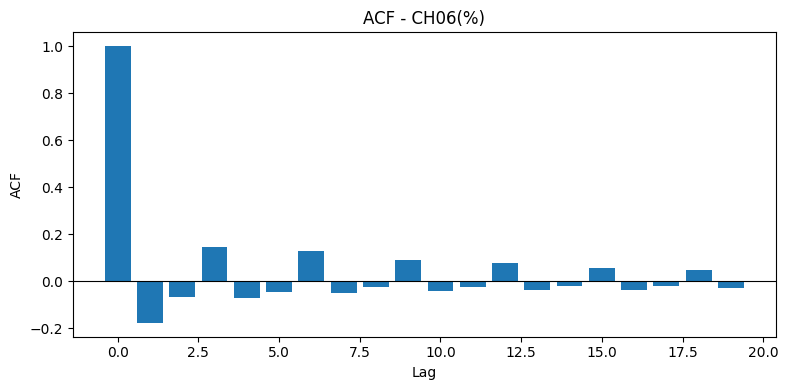

In [31]:
num_lags = 20

for col in first_diff.columns:
    series = first_diff[col].dropna()
    if len(series) < 2:
        print(f"Skipping {col}: not enough data")
        continue

    acf_vals = acf(series, nlags=num_lags-1)

    plt.figure(figsize=(8, 4))
    plt.bar(range(num_lags), acf_vals[:num_lags])
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(f"ACF - {col}")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.show()


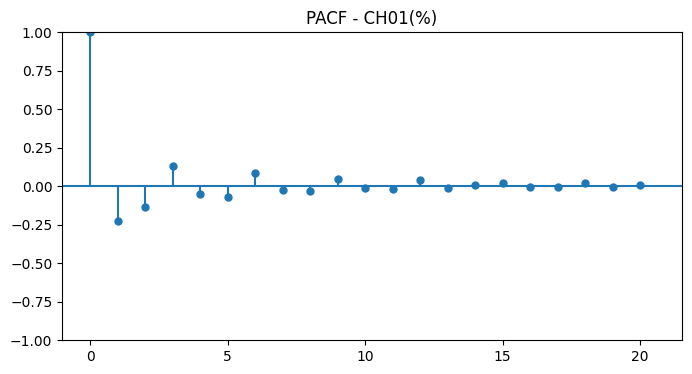

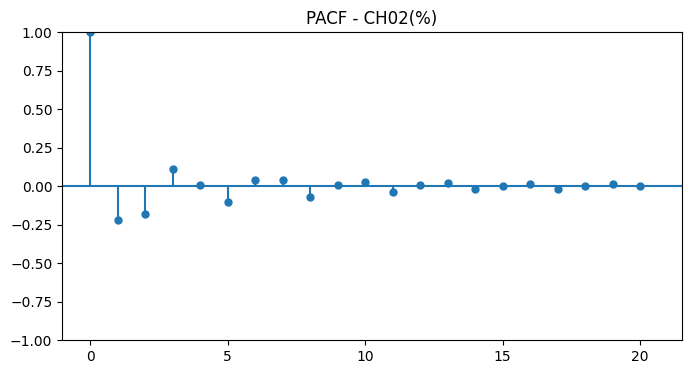

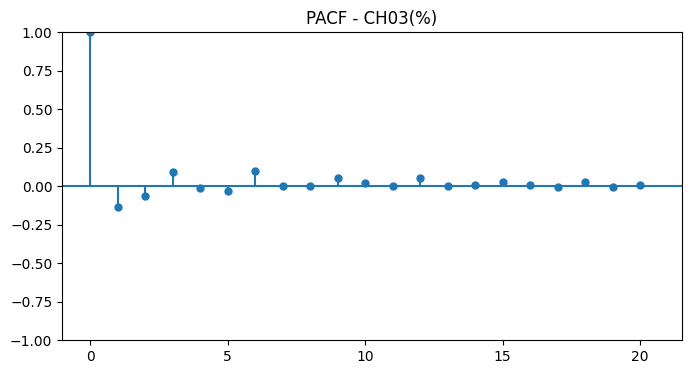

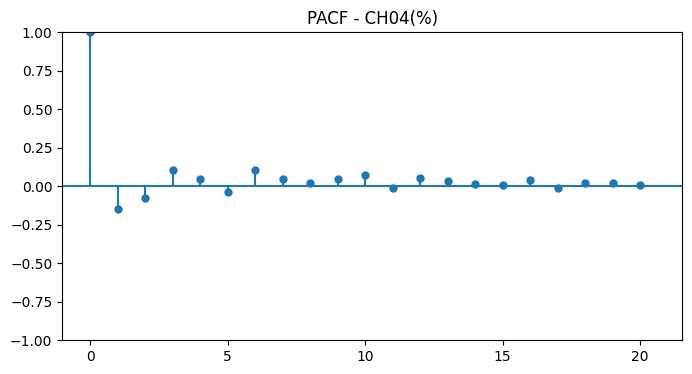

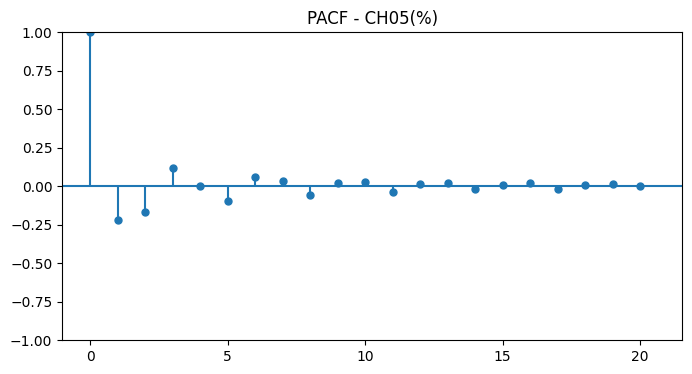

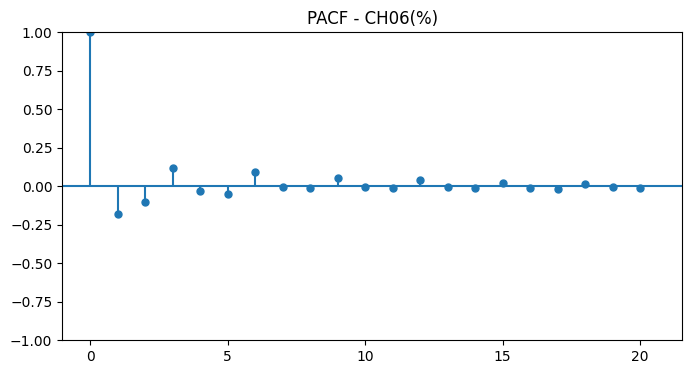

In [32]:
for column in first_diff.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_pacf(first_diff[column].dropna(), lags=20, ax=ax, title=f'PACF - {column}')
    plt.show()

In [33]:
# Choose one channel
y = first_diff['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest 30 minutes and aggregate duplicates
y.index = y.index.round('30min')
y = y.groupby(level=0).mean()

# Enforce strict 30-min frequency
y = y.asfreq('60min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [34]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-754.492, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-767.624, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-766.624, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-765.299, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-763.346, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-765.791, Time=0.04 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.578 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   88
Model:                        SARIMAX   Log Likelihood                 384.812
Date:                Wed, 01 Apr 2026   AIC                           -767.624
Time:                        15:47:42   BIC                           -765.147
Sample:                    02-27-2025   HQIC                          -766.626
                         - 03-03-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      9.318e-06   7.54e-07     12.350      0.000    7.84e-06    1.08e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):               101.49
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               0.10   Skew:                            -1.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

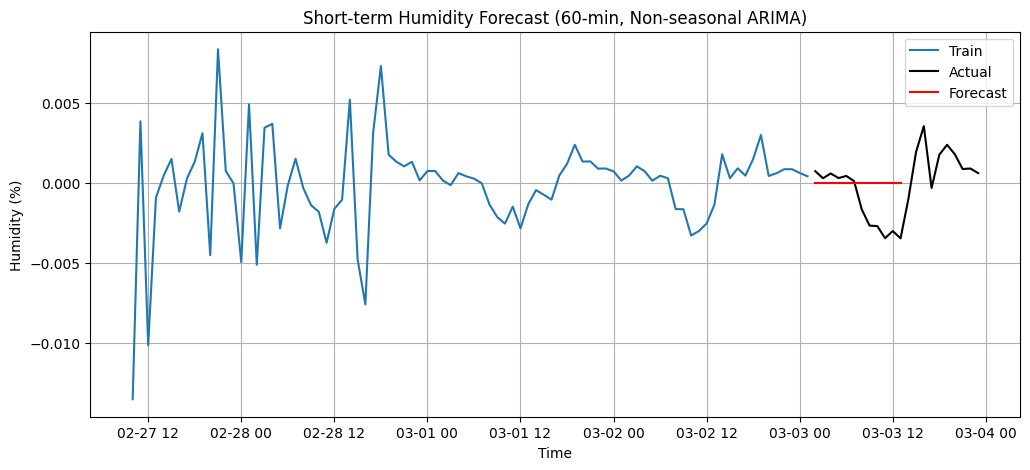

In [35]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='60min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (60-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


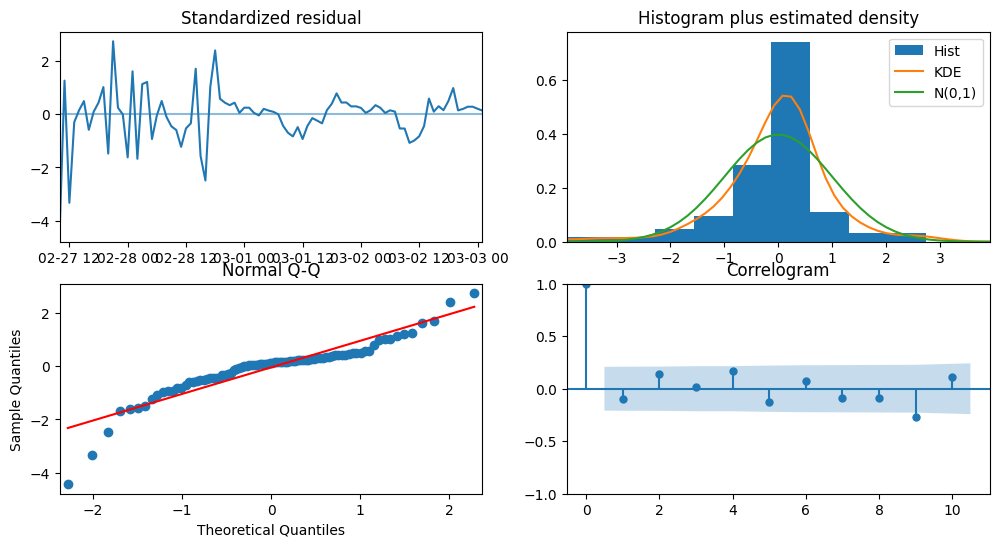

In [36]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [37]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 0.001621346651868297
Simple  ARIMA(1,0,1) MAE: 0.0016202656088180128


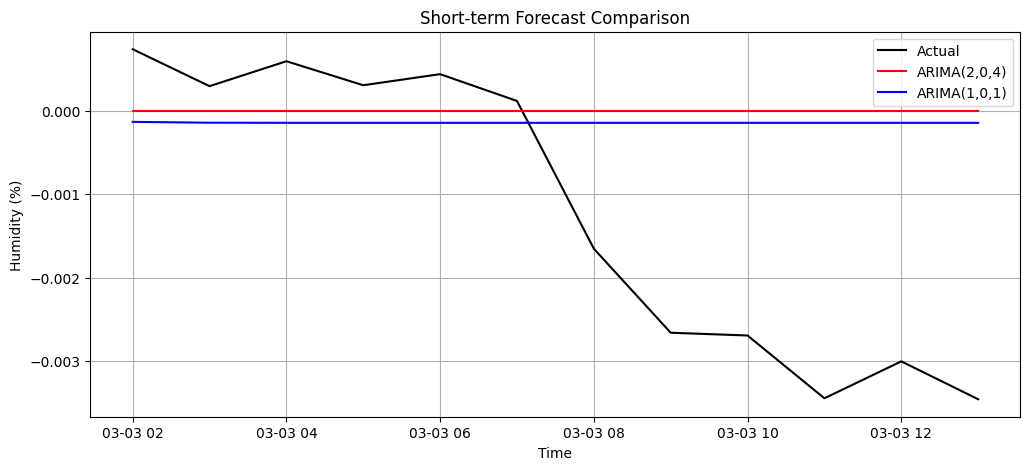

In [38]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
